# 03 — Single Tree Baseline

Train a single XGBoost `seed_baseline` expert, tune hyperparameters with Optuna, and evaluate performance with SHAP, calibration, and per-round analysis.

In [1]:
import sys
sys.path.insert(0, "..")

import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import optuna
import shap

from src.config import (
    FIRST_YEAR, LAST_YEAR, SKIP_YEARS,
    XGBOOST_PARAMS, OPTUNA_SEARCH_SPACE, OPTUNA_N_TRIALS,
)
from src.features.pipeline import build_features_for_split
from src.models.tree_expert import TreeExpert, tune_expert_hyperparams
from src.evaluation.metrics import compute_all_metrics, compute_logloss, compute_round_breakdown
from src.evaluation.calibration import compute_calibration_curve, compute_calibration_error

logging.basicConfig(level=logging.INFO)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Data Split

In [2]:
all_seasons = [y for y in range(FIRST_YEAR, LAST_YEAR + 1) if y not in SKIP_YEARS]
test_seasons = [2024, 2025]
train_seasons = [y for y in all_seasons if y not in test_seasons]

train_fs, test_fs = build_features_for_split(train_seasons, test_seasons)

print(f"Train: {train_fs.X.shape[0]} games, {train_fs.X.shape[1]} features")
print(f"  Seasons: {train_seasons[0]}–{train_seasons[-1]} ({len(train_seasons)} seasons)")
print(f"Test:  {test_fs.X.shape[0]} games, {test_fs.X.shape[1]} features")
print(f"  Seasons: {test_seasons}")
print(f"\nTarget balance (train): {train_fs.y.mean():.3f}")
print(f"Target balance (test):  {test_fs.y.mean():.3f}")
print(f"\nFeature names: {train_fs.feature_names[:10]} ...")

INFO:src.data.kaggle_loader:Loading DEV table from /Users/austinsalter/Documents/Projects/March-Madness-MOE/data/raw/kenpom/DEV _ March Madness.csv
INFO:src.data.kaggle_loader:Loaded DEV table: 8315 rows, 24 seasons (2002–2025), 38 columns
INFO:src.data.kaggle_loader:Loading pomeroy ratings from /Users/austinsalter/Documents/Projects/March-Madness-MOE/data/cache/kenpom_pomeroy_ratings.parquet
INFO:src.data.kaggle_loader:Loaded pomeroy ratings: 8679 rows, 25 seasons
INFO:src.data.kaggle_loader:Pomeroy merge: 7607/8315 matched. 708 unmatched (mostly non-tournament): ['Miami', 'Pennsylvania', 'Little Rock', 'McNeese', 'IU Indianapolis', 'Sam Houston', 'Missouri State', 'Louisiana', 'Miami (OH)', 'Charleston']
INFO:src.data.kaggle_loader:Final KenPom dataset: 8314 rows, 43 columns, seasons 2002–2025
INFO:src.data.tournament_data:Dropping 63 First Four / play-in games
INFO:src.data.tournament_data:Loaded 1386 tournament matchups across 22 seasons (2003–2025)
INFO:src.data.merge:Merge comple

Train: 1262 games, 39 features
  Seasons: 2003–2023 (20 seasons)
Test:  126 games, 39 features
  Seasons: [2024, 2025]

Target balance (train): 0.708
Target balance (test):  0.746

Feature names: ['adjde_delta', 'adjem_delta', 'adjoe_delta', 'adjtempo_delta', 'avg_height_delta', 'bench_delta', 'def_arate_delta', 'def_blockpct_delta', 'def_fg2pct_delta', 'def_fg3pct_delta'] ...


## 2. Default Params Baseline

In [ ]:
default_expert = TreeExpert("seed_baseline")
default_expert.fit(train_fs, val_fs=test_fs)

default_preds = default_expert.predict_proba(test_fs)
default_metrics = compute_all_metrics(
    test_fs.y.values, default_preds, rounds=test_fs.meta["round"].values
)

print("Default XGBoost Metrics (test set):")
for k, v in default_metrics.items():
    print(f"  {k}: {v:.4f}")

print(f"\nBest iteration: {default_expert.model.best_iteration}")
print(f"Default params: {XGBOOST_PARAMS}")

## 3. Learning Curve (Default)

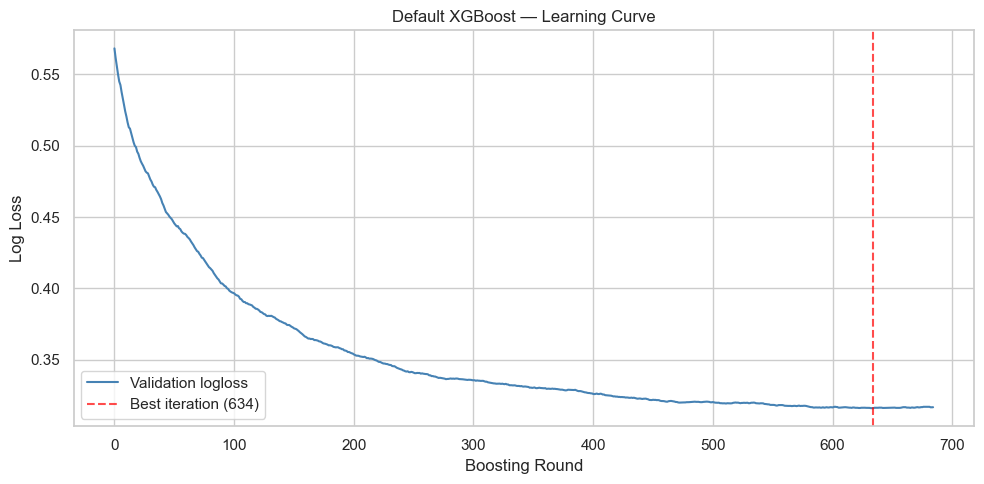

In [4]:
evals_result = default_expert.model.evals_result()
eval_set_name = list(evals_result.keys())[0]
val_logloss = evals_result[eval_set_name]["logloss"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(val_logloss)), val_logloss, label="Validation logloss", color="steelblue", linewidth=1.5)
best_iter = default_expert.model.best_iteration
ax.axvline(best_iter, color="red", linestyle="--", alpha=0.7, label=f"Best iteration ({best_iter})")
ax.set_xlabel("Boosting Round")
ax.set_ylabel("Log Loss")
ax.set_title("Default XGBoost — Learning Curve")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Optuna Tuning

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {}
    for param_name, (lo, hi) in OPTUNA_SEARCH_SPACE.items():
        if isinstance(lo, int) and isinstance(hi, int):
            params[param_name] = trial.suggest_int(param_name, lo, hi)
        else:
            params[param_name] = trial.suggest_float(param_name, lo, hi)
    
    expert = TreeExpert("seed_baseline", params=params)
    expert.fit(train_fs, val_fs=test_fs)
    preds = expert.predict_proba(test_fs)
    return compute_logloss(test_fs.y.values, preds)

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=OPTUNA_N_TRIALS, timeout=600)

print(f"Best logloss: {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"\nTotal trials: {len(study.trials)}")

## 5. Optuna Optimization History

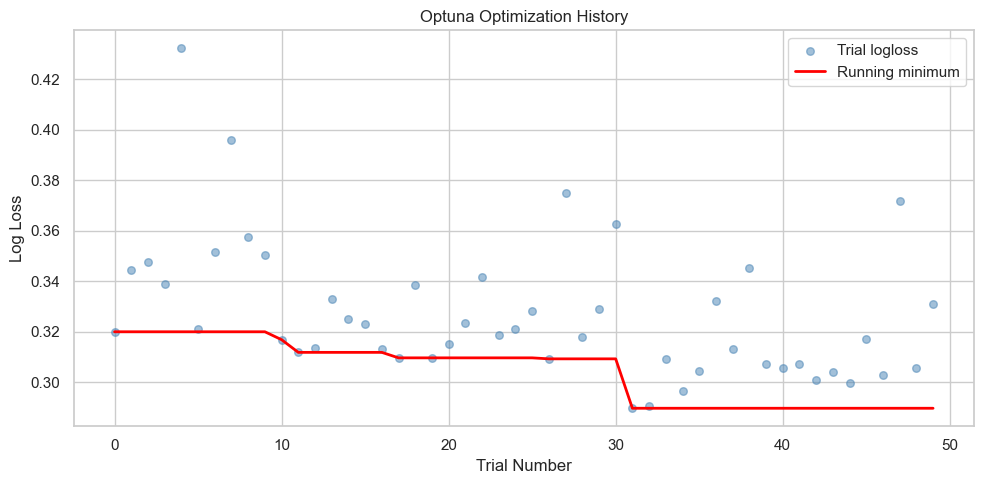

In [6]:
trial_numbers = [t.number for t in study.trials]
trial_values = [t.value for t in study.trials]

# Compute running minimum
running_min = np.minimum.accumulate(trial_values)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(trial_numbers, trial_values, alpha=0.5, s=30, color="steelblue", label="Trial logloss")
ax.plot(trial_numbers, running_min, color="red", linewidth=2, label="Running minimum")
ax.set_xlabel("Trial Number")
ax.set_ylabel("Log Loss")
ax.set_title("Optuna Optimization History")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Optuna Parameter Importance

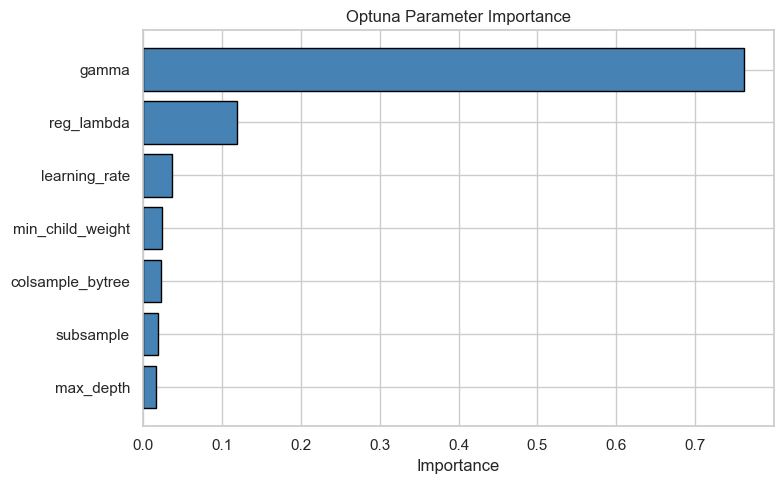

In [7]:
param_importances = optuna.importance.get_param_importances(study)

fig, ax = plt.subplots(figsize=(8, 5))
names = list(param_importances.keys())
values = list(param_importances.values())
ax.barh(names[::-1], values[::-1], color="steelblue", edgecolor="black")
ax.set_xlabel("Importance")
ax.set_title("Optuna Parameter Importance")
plt.tight_layout()
plt.show()

## 7. Hyperparameter Interaction Heatmaps

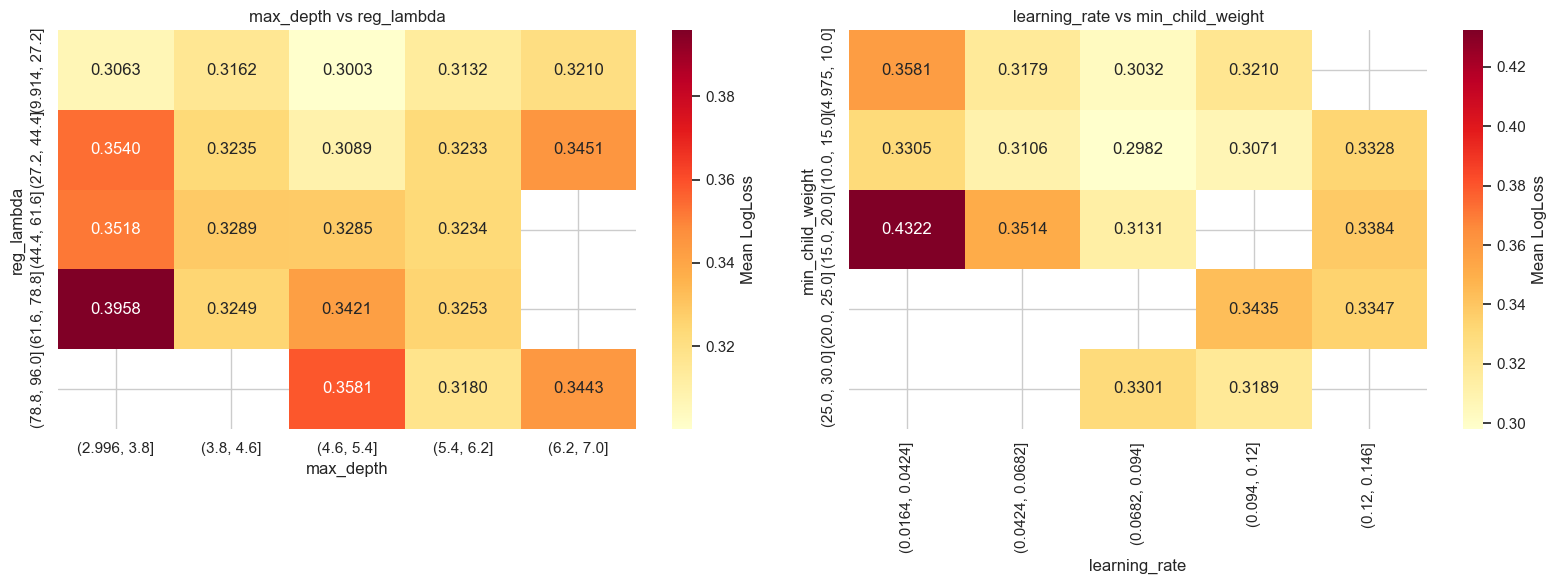

In [8]:
# Extract trial data into a DataFrame
trial_data = []
for t in study.trials:
    row = {**t.params, "value": t.value}
    trial_data.append(row)
trials_df = pd.DataFrame(trial_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 1: max_depth x reg_lambda
if "max_depth" in trials_df.columns and "reg_lambda" in trials_df.columns:
    trials_df["max_depth_bin"] = pd.cut(trials_df["max_depth"], bins=5)
    trials_df["reg_lambda_bin"] = pd.cut(trials_df["reg_lambda"], bins=5)
    pivot1 = trials_df.pivot_table(values="value", index="reg_lambda_bin", columns="max_depth_bin", aggfunc="mean")
    sns.heatmap(pivot1, annot=True, fmt=".4f", cmap="YlOrRd", ax=axes[0], cbar_kws={"label": "Mean LogLoss"})
    axes[0].set_title("max_depth vs reg_lambda")
    axes[0].set_xlabel("max_depth")
    axes[0].set_ylabel("reg_lambda")

# Heatmap 2: learning_rate x min_child_weight
if "learning_rate" in trials_df.columns and "min_child_weight" in trials_df.columns:
    trials_df["lr_bin"] = pd.cut(trials_df["learning_rate"], bins=5)
    trials_df["mcw_bin"] = pd.cut(trials_df["min_child_weight"], bins=5)
    pivot2 = trials_df.pivot_table(values="value", index="mcw_bin", columns="lr_bin", aggfunc="mean")
    sns.heatmap(pivot2, annot=True, fmt=".4f", cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "Mean LogLoss"})
    axes[1].set_title("learning_rate vs min_child_weight")
    axes[1].set_xlabel("learning_rate")
    axes[1].set_ylabel("min_child_weight")

plt.tight_layout()
plt.show()

## 8. Optuna Parallel Coordinate (Top 10 Trials)

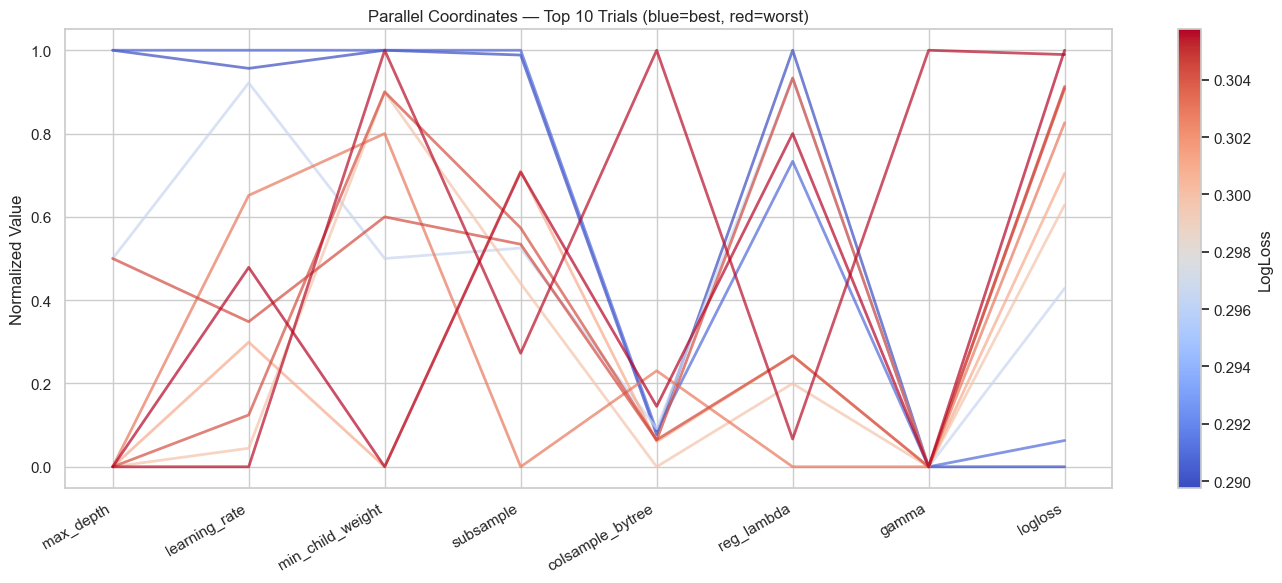

In [9]:
# Get top 10 trials by value
sorted_trials = sorted(study.trials, key=lambda t: t.value)
top_10 = sorted_trials[:10]

# Build data for parallel coordinate plot
top_data = []
for t in top_10:
    row = {**t.params, "logloss": t.value}
    top_data.append(row)
top_df = pd.DataFrame(top_data)

# Normalize columns to [0, 1] for parallel coordinate display
plot_cols = [c for c in top_df.columns if c != "logloss"]
normed = top_df.copy()
for col in plot_cols:
    cmin, cmax = normed[col].min(), normed[col].max()
    if cmax > cmin:
        normed[col] = (normed[col] - cmin) / (cmax - cmin)
    else:
        normed[col] = 0.5
# Also normalize logloss for coloring
normed["logloss_norm"] = (normed["logloss"] - normed["logloss"].min()) / (
    normed["logloss"].max() - normed["logloss"].min() + 1e-10
)

fig, ax = plt.subplots(figsize=(14, 6))
all_cols = plot_cols + ["logloss"]

cmap = plt.cm.coolwarm
for idx, row in normed.iterrows():
    color = cmap(row["logloss_norm"])
    # For logloss axis, normalize it too
    vals = [row[c] for c in plot_cols]
    logloss_norm_val = row["logloss_norm"]
    vals.append(logloss_norm_val)
    ax.plot(range(len(all_cols)), vals, color=color, alpha=0.7, linewidth=2)

ax.set_xticks(range(len(all_cols)))
ax.set_xticklabels(all_cols, rotation=30, ha="right")
ax.set_ylabel("Normalized Value")
ax.set_title("Parallel Coordinates — Top 10 Trials (blue=best, red=worst)")

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(
    top_df["logloss"].min(), top_df["logloss"].max()
))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label="LogLoss")

plt.tight_layout()
plt.show()

## 9. Retrain with Best Params

In [ ]:
tuned_expert = TreeExpert("seed_baseline", params=study.best_params)
tuned_expert.fit(train_fs, val_fs=test_fs)

tuned_preds = tuned_expert.predict_proba(test_fs)
tuned_metrics = compute_all_metrics(
    test_fs.y.values, tuned_preds, rounds=test_fs.meta["round"].values
)

# Comparison table
comparison = pd.DataFrame({
    "Default": default_metrics,
    "Tuned": tuned_metrics,
}).T
comparison["delta"] = comparison.loc["Tuned"] - comparison.loc["Default"]
print("Default vs Tuned comparison:")
comparison

## 10. Tuned vs Default Learning Curves

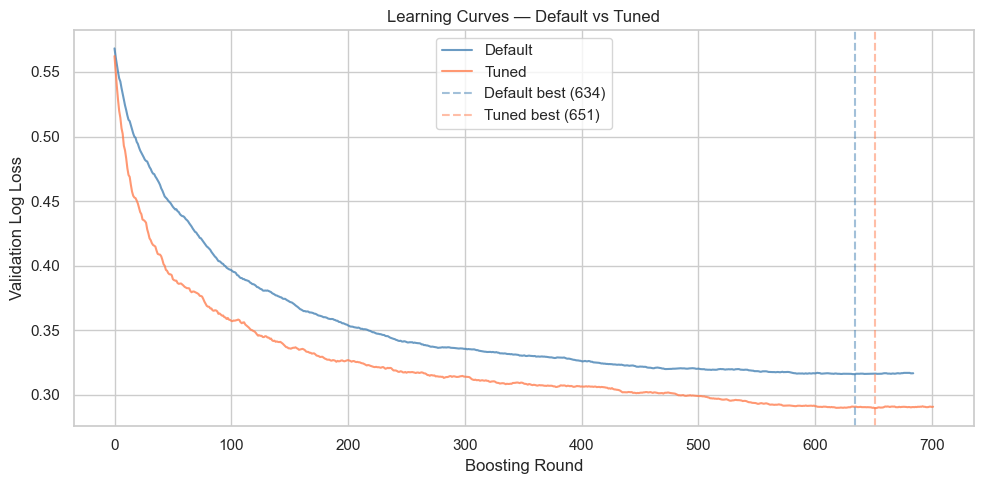

In [11]:
default_evals = default_expert.model.evals_result()
tuned_evals = tuned_expert.model.evals_result()

default_key = list(default_evals.keys())[0]
tuned_key = list(tuned_evals.keys())[0]

default_ll = default_evals[default_key]["logloss"]
tuned_ll = tuned_evals[tuned_key]["logloss"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(default_ll)), default_ll, label="Default", color="steelblue", linewidth=1.5, alpha=0.8)
ax.plot(range(len(tuned_ll)), tuned_ll, label="Tuned", color="coral", linewidth=1.5, alpha=0.8)
ax.axvline(default_expert.model.best_iteration, color="steelblue", linestyle="--", alpha=0.5,
           label=f"Default best ({default_expert.model.best_iteration})")
ax.axvline(tuned_expert.model.best_iteration, color="coral", linestyle="--", alpha=0.5,
           label=f"Tuned best ({tuned_expert.model.best_iteration})")
ax.set_xlabel("Boosting Round")
ax.set_ylabel("Validation Log Loss")
ax.set_title("Learning Curves — Default vs Tuned")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Feature Importance (3 Types)

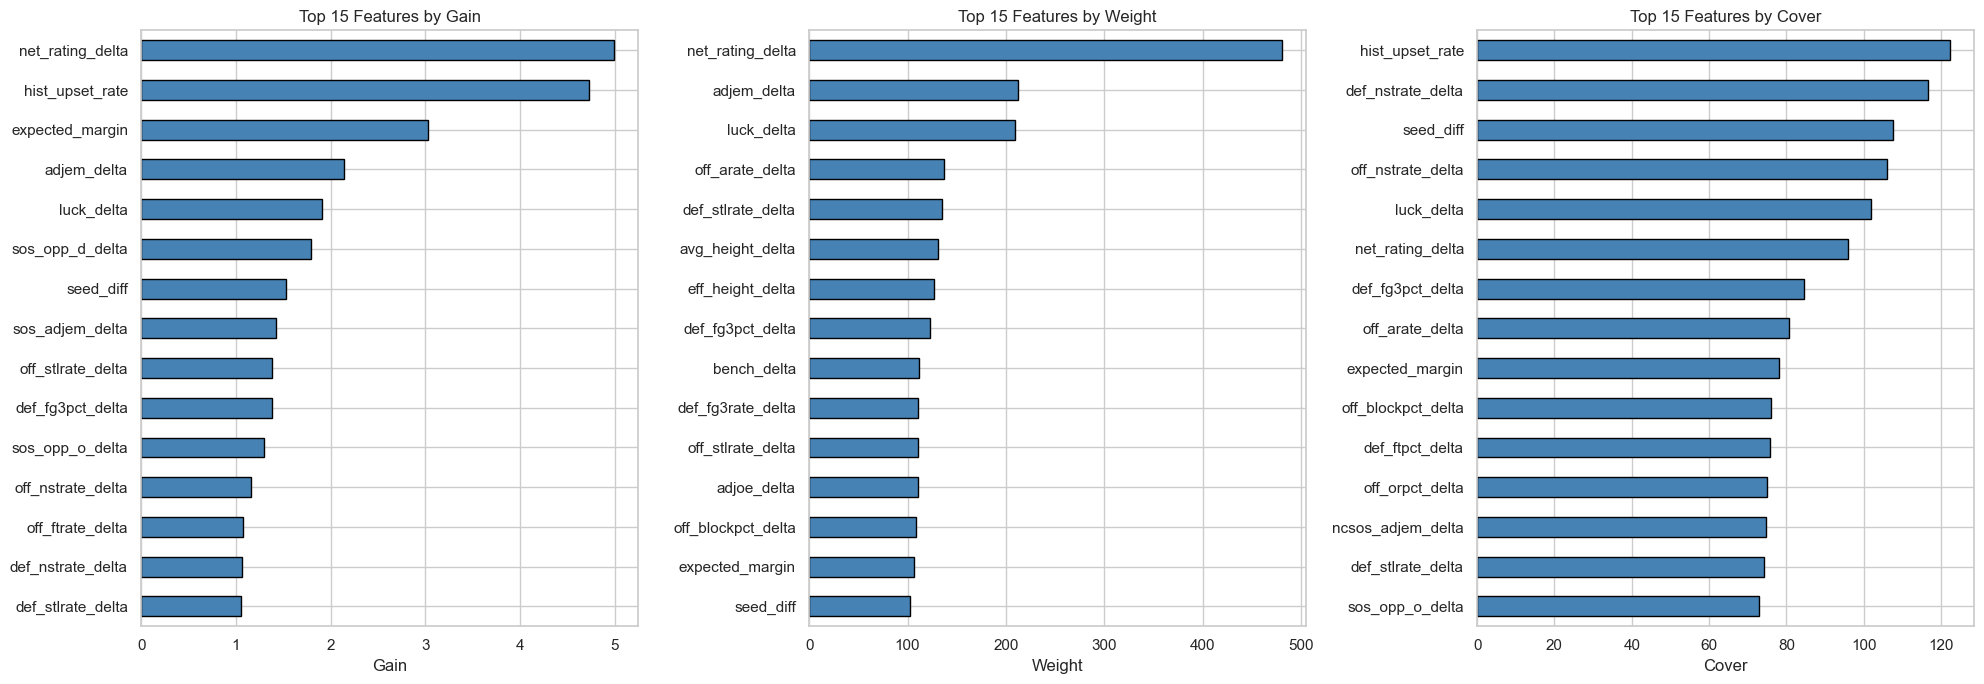

In [12]:
booster = tuned_expert.model.get_booster()

importance_types = ["gain", "weight", "cover"]
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, imp_type in zip(axes, importance_types):
    scores = booster.get_score(importance_type=imp_type)
    imp_series = pd.Series(scores).sort_values(ascending=False).head(15)
    imp_series.sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(f"Top 15 Features by {imp_type.capitalize()}")
    ax.set_xlabel(imp_type.capitalize())

plt.tight_layout()
plt.show()

## 12. SHAP Summary Plot

In [ ]:
# Use the subsetted features for SHAP (must match what the model was trained on)
X_shap = tuned_expert._prepare_X(test_fs.X, test_fs.ranking_targets)
explainer = shap.TreeExplainer(tuned_expert.model)
shap_values = explainer.shap_values(X_shap)

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
plt.title("SHAP Summary — Tuned Seed Baseline Expert")
plt.tight_layout()
plt.show()

## 13. SHAP Partial Dependence (Top 5 Features)

In [ ]:
# Get top 5 features by gain
gain_scores = booster.get_score(importance_type="gain")
top5_features = pd.Series(gain_scores).sort_values(ascending=False).head(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_shap.values,
    feature_names=X_shap.columns.tolist(),
)

for i, feat in enumerate(top5_features):
    feat_idx = X_shap.columns.tolist().index(feat)
    ax = axes_flat[i]
    ax.scatter(
        X_shap[feat].values,
        shap_values[:, feat_idx],
        alpha=0.5, s=15, color="steelblue"
    )
    ax.set_xlabel(feat)
    ax.set_ylabel("SHAP value")
    ax.set_title(f"SHAP Dependence: {feat}")
    ax.axhline(0, color="grey", linestyle="--", alpha=0.5)

# Remove the unused 6th subplot
axes_flat[5].set_visible(False)

plt.tight_layout()
plt.show()

## 14. Per-Round Performance

In [15]:
round_breakdown = compute_round_breakdown(
    test_fs.y.values, tuned_preds, test_fs.meta["round"].values
)

round_labels = {1: "R64", 2: "R32", 3: "S16", 4: "E8", 5: "F4", 6: "Championship"}
round_breakdown["round_name"] = round_breakdown["round"].map(round_labels)

print("Per-Round Performance (Tuned Model):")
round_breakdown

Per-Round Performance (Tuned Model):


,round,n_games,accuracy,logloss,brier_score,round_name
0,1,64,0.890625,0.317651,0.096245,R64
1,2,32,0.968750,0.202273,0.052625,R32
2,3,16,0.750000,0.388678,0.135091,S16
3,4,8,1.000000,0.178395,0.036023,E8
4,5,4,1.000000,0.302291,0.085528,F4
5,6,2,0.500000,0.426785,0.156862,Championship


## 15. Per-Round Metrics Visualization

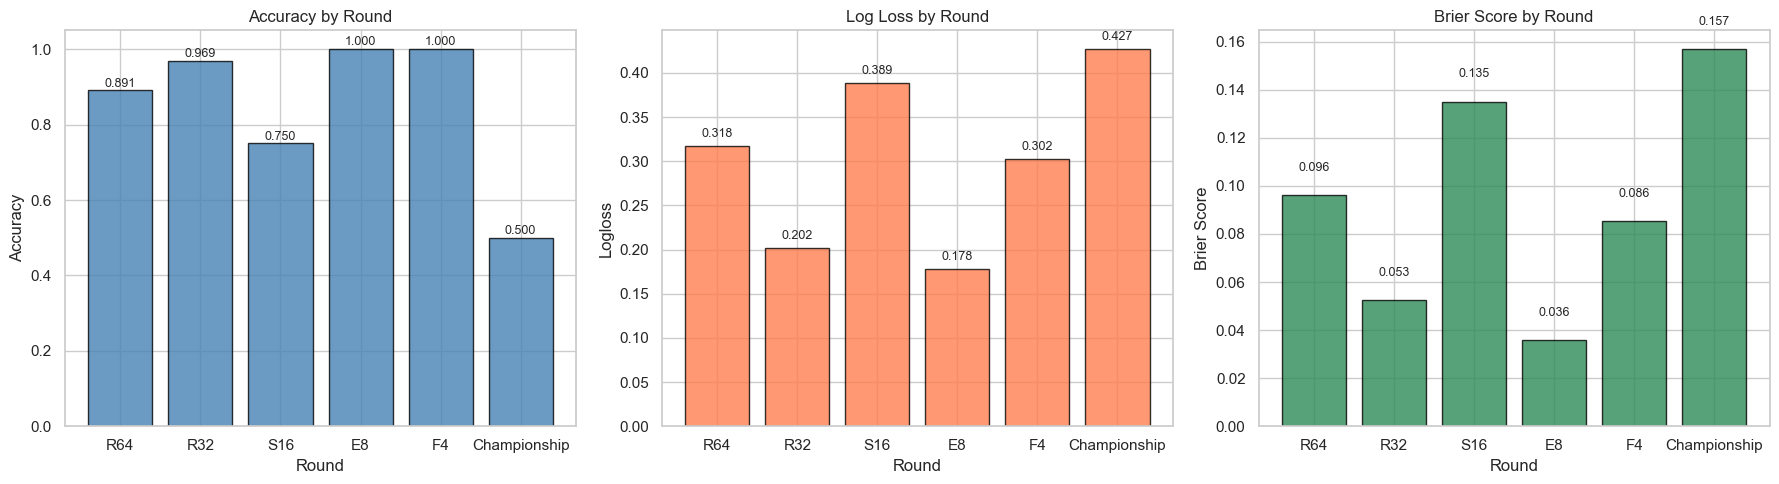

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metric_cols = ["accuracy", "logloss", "brier_score"]
colors = ["steelblue", "coral", "seagreen"]
titles = ["Accuracy by Round", "Log Loss by Round", "Brier Score by Round"]

for ax, metric, color, title in zip(axes, metric_cols, colors, titles):
    ax.bar(
        round_breakdown["round_name"],
        round_breakdown[metric],
        color=color, edgecolor="black", alpha=0.8
    )
    ax.set_title(title)
    ax.set_xlabel("Round")
    ax.set_ylabel(metric.replace("_", " ").title())
    # Add value labels on bars
    for j, v in enumerate(round_breakdown[metric]):
        ax.text(j, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 16. Prediction Distribution

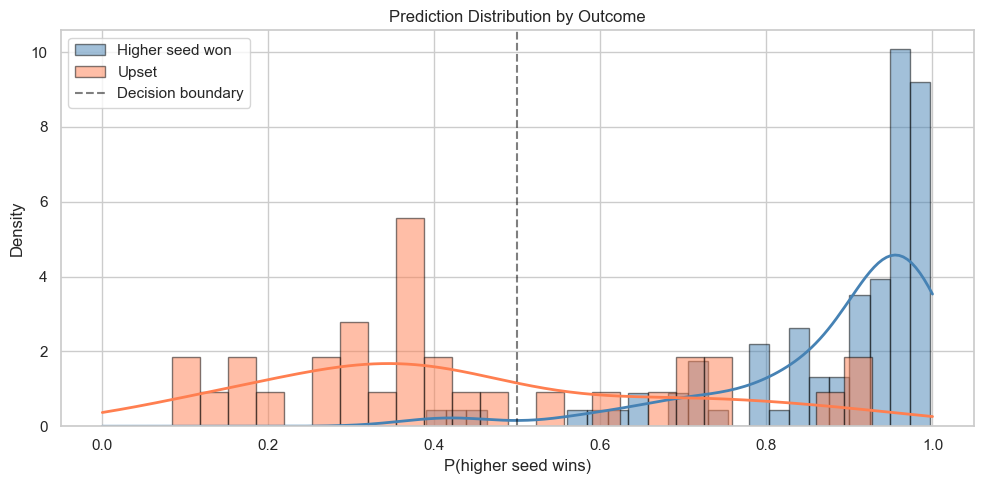

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

mask_win = test_fs.y.values == 1
mask_upset = test_fs.y.values == 0

ax.hist(tuned_preds[mask_win], bins=25, alpha=0.5, color="steelblue",
        label="Higher seed won", edgecolor="black", density=True)
ax.hist(tuned_preds[mask_upset], bins=25, alpha=0.5, color="coral",
        label="Upset", edgecolor="black", density=True)

# KDE overlay
from scipy.stats import gaussian_kde
x_grid = np.linspace(0, 1, 200)
if mask_win.sum() > 1:
    kde_win = gaussian_kde(tuned_preds[mask_win])
    ax.plot(x_grid, kde_win(x_grid), color="steelblue", linewidth=2)
if mask_upset.sum() > 1:
    kde_upset = gaussian_kde(tuned_preds[mask_upset])
    ax.plot(x_grid, kde_upset(x_grid), color="coral", linewidth=2)

ax.axvline(0.5, color="black", linestyle="--", alpha=0.5, label="Decision boundary")
ax.set_xlabel("P(higher seed wins)")
ax.set_ylabel("Density")
ax.set_title("Prediction Distribution by Outcome")
ax.legend()
plt.tight_layout()
plt.show()

## 17. Calibration Reliability Diagram

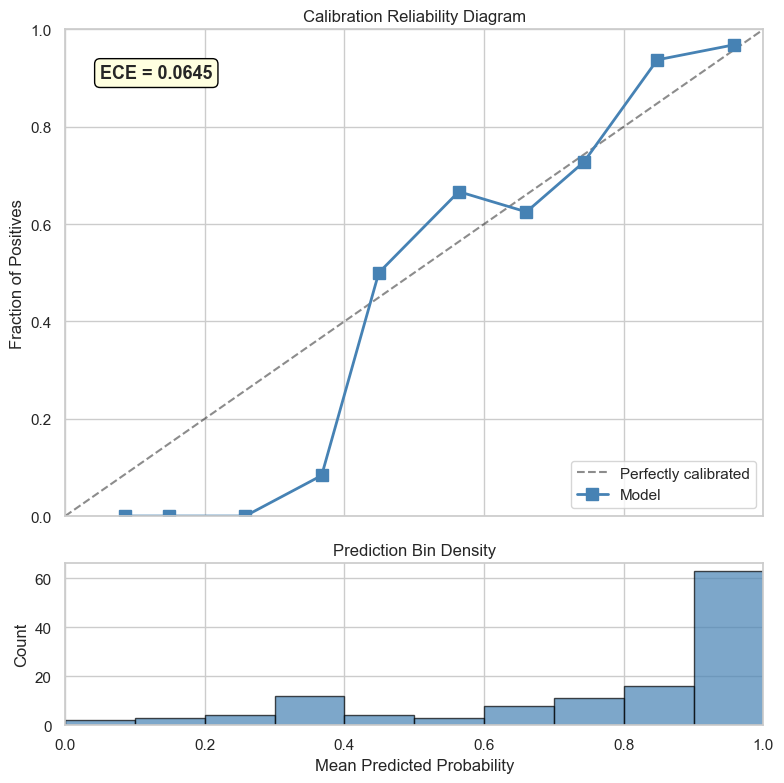

Expected Calibration Error (ECE): 0.0645


In [18]:
fraction_pos, mean_pred = compute_calibration_curve(test_fs.y.values, tuned_preds, n_bins=10)
ece = compute_calibration_error(test_fs.y.values, tuned_preds, n_bins=10)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)

# Reliability diagram
ax1.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfectly calibrated")
ax1.plot(mean_pred, fraction_pos, "s-", color="steelblue", markersize=8, linewidth=2, label="Model")
ax1.set_ylabel("Fraction of Positives")
ax1.set_title("Calibration Reliability Diagram")
ax1.annotate(f"ECE = {ece:.4f}", xy=(0.05, 0.9), fontsize=13, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="black"))
ax1.legend(loc="lower right")
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# Bin density histogram
ax2.hist(tuned_preds, bins=10, range=(0, 1), color="steelblue", edgecolor="black", alpha=0.7)
ax2.set_xlabel("Mean Predicted Probability")
ax2.set_ylabel("Count")
ax2.set_title("Prediction Bin Density")

plt.tight_layout()
plt.show()

print(f"Expected Calibration Error (ECE): {ece:.4f}")